In this notebook, we implement GPT-2 with a context length of 512 from scratch and pre-train it for NNP (Next Number Prediction).
Given an input (4,5,6,7,8), we expect the output (5,6,7,8,9).


All you are expected to do is fill in missing pieces in the training loop.


In [2]:
import torch
import torch.nn as nn
import math
import numpy as np

In [3]:
def get_gpu_statistics():
  available, total = torch.cuda.mem_get_info()
  print(f"Available VRAM: {available/1024/1024}, Total VRAM: {total/1024/1024}")

In [4]:
get_gpu_statistics()

Available VRAM: 14807.8125, Total VRAM: 14912.6875


In [ ]:
class Decoder(nn.Module):
    def __init__(
        self,
        n_head: int,
        emb_size: int,
        max_length: int,
        attention_drop_prob: float,
    ):
        super().__init__()
        self.n_head = n_head #number of attention heads
        self.emb_size = emb_size #embedding/token dimensionality
        self.max_length = max_length #context size of GPT-2 (512)
        self.attention_drop_prob = attention_drop_prob #dropout

        #multiply embeddings with W_Q, W_K, W_V matrices (hint: these matrices have been concatenated together here)
        self.project_layer = nn.Linear(self.emb_size, 3 * self.emb_size)

        self.attention_drop = nn.Dropout(self.attention_drop_prob)

        # attention mask for masked self attention
        # register_buffer puts data automatically to the right device.
        self.register_buffer(
            "masked_attention",
            torch.tril(torch.ones(self.max_length, self.max_length, dtype=torch.bool)).reshape(
                1, 1, self.max_length, self.max_length
            ),
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x: torch.tensor):
        # we extract Batch Size (B), Sequence Length (T) & Embedding size (E)
        # T is input length
        B, T, E = x.size()

        #split & retrieve k,v,q matrices
        # project_layer(x): (B, T, E) -> (B, T, 3*E)
        q, k, v  = self.project_layer(x).split(self.emb_size, dim=2)

        # get k, v, q per attention head: (B, T, E) -> (B, T, n_head, head_dim) -> (B, n_head, T, head_dim)
        head_dim = self.emb_size // self.n_head # paper head_dim := d_k
        k = k.view(B, T, self.n_head, head_dim).transpose(1,2) # -> (B, n_head, T, head_dim)
        v = v.view(B, T, self.n_head, head_dim).transpose(1,2) # -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, head_dim).transpose(1,2) # -> (B, n_head, T, head_dim)

        # (B, n_head, T, head_dim) @ (B, n_head, head_dim, T) -> (B, n_head, T, T)
        # here we retrieve attention scores and normalize
        attention_logits = q @ k.transpose(2, 3) / math.sqrt(head_dim) # -> (B, n_head, T, T)

        # mask attention here (since this is masked self attention, we ony attend to prior tokens)
        # set the upper triangle to -inf
        # (1, 1, max_length, max_length): if T=10, we just need (1, 1, 10, 10)
        masked_attention_logits = attention_logits.masked_fill(
            ~self.masked_attention[:, :, :T, :T],
            torch.finfo(attention_logits.dtype).min
        )
        # above is: masked_attention_logits = attention_logits.masked_fill(mask == 0, float("-inf"))
        attention_weights = self.softmax(masked_attention_logits)
        attention_weights = self.attention_drop(attention_weights)

        # final step to compute output of Masked Self Attention layer (what is the last missing step?)
        # (B, n_head, T, T) @ (B, n_head, T, head_dim) -> (B, n_head, T, head_dim)
        x = attention_weights @ v  # (B, n_head, T, head_dim)
        # concat by n_head
        #x = x.view(B, T, E)
        # (B, n_head, T, head_dim) -> transpose: (B, T, n_head, head_dim) -> view: (B, T, E)
        x = x.transpose(1, 2).contiguous().view(B, T, E)  # -> (B, T, E)
        # .contiguous() forces PyTorch to actually copy the data into a new, properly laid-out block of memory before .view() reshapes it.
        # first transpose then view, so we need contiguous
        # .transpose() doesn't actually move data in memory, it just changes how PyTorch interprets the tensor's shape by swapping strides.

        return x



In [6]:

class MinGPT(nn.Module):
    def __init__(
        self,
        emb_size: int = 768,
        max_length: int = 512,
        vocab_size: int = 500,
        n_head: int = 12,
        decoder_n_layer: int = 8,
        embedding_drop_prob: float = 0.1,
        attention_drop_prob: float = 0.1,
        project_drop_prob: float = 0.1,
    ):
        assert emb_size % n_head == 0
        super().__init__()

        self.emb_size = emb_size
        self.max_length = max_length
        self.vocab_size = vocab_size

        self.n_head = n_head
        self.decoder_n_layer = decoder_n_layer

        self.embedding_drop_prob = embedding_drop_prob
        self.attention_drop_prob = attention_drop_prob
        self.project_drop_prob = project_drop_prob

        self.model = nn.ModuleDict(
            dict(
                word_to_embedding=nn.Embedding(self.max_length, self.emb_size),
                position_to_embedding=nn.Embedding(self.vocab_size, self.emb_size),
                embedding_drop=nn.Dropout(self.embedding_drop_prob),
                decoder=nn.ModuleList(
                    [
                        Decoder(
                            self.n_head,
                            self.emb_size,
                            self.max_length,
                            self.attention_drop_prob,
                        )
                        for _ in range(self.decoder_n_layer)
                    ]
                ),
            )
        )
        self.lm_head = nn.Linear(self.emb_size, self.vocab_size, bias=False)
        #computes average CE Loss over an entire sequence or batch of sequences
        self.loss_func = nn.CrossEntropyLoss(reduction = 'mean')

    def forward(self, tokens, labels=None):
        assert tokens.max() < self.vocab_size, \
            f"Token index {tokens.max()} out of vocabulary (size {self.vocab_size})"
        #
        emb = self.model.word_to_embedding(tokens)
        pos_idx = torch.arange(tokens.size(-1), device=tokens.device)
        pos = self.model.position_to_embedding(pos_idx)
        # emb and pos: (B, T, emb_size)
        x = self.model.embedding_drop(emb + pos) # x: (B, T, emb_size)
        for decoder_layer in self.model.decoder:
            x = decoder_layer(x) # x: (B, T, emb_size)

        # (batch size, sequence length, vocab size)
        # (B, T, vocab_size)
        logits = self.lm_head(x)

        if labels is not None:
            #use the loss function to compute the loss between logits and labels
            #remember the shape of logits above and the shape of labels is (batch size, sequence length)
            # logits: (B, T, vocab_size) -> (B*T, vocab_size)
            # labels: (B, T)             -> (B*T,)
            loss = self.loss_func(
                logits.view(-1, self.vocab_size),
                labels.view(-1)
            )
        else:
            loss = None
        return logits, loss

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MinGPT()
model.to(device)

MinGPT(
  (model): ModuleDict(
    (word_to_embedding): Embedding(512, 768)
    (position_to_embedding): Embedding(500, 768)
    (embedding_drop): Dropout(p=0.1, inplace=False)
    (decoder): ModuleList(
      (0-7): 8 x Decoder(
        (project_layer): Linear(in_features=768, out_features=2304, bias=True)
        (attention_drop): Dropout(p=0.1, inplace=False)
        (softmax): Softmax(dim=-1)
      )
    )
  )
  (lm_head): Linear(in_features=768, out_features=500, bias=False)
  (loss_func): CrossEntropyLoss()
)

In [8]:
def generate_input_label(size, vocab_size, max_length):
    assert size <= max_length
    inputs = [vocab_size - 1] * max_length
    labels = [-100] * max_length
    sample_size = np.random.randint(vocab_size)
    c = 0
    for i in range(max(0, sample_size - size), sample_size):
        inputs[c] = i
        if c < size - 1:
            labels[c] = i + 1
        else:
            labels[c] = vocab_size - 1
        c += 1
    return inputs, labels


def get_inputs_labels(batch_size=4, vocab_size=400):
    inputs = []
    labels = []
    max_length = 500
    for i in range(batch_size):
        length = max_length
        _inputs, _labels = generate_input_label(length, vocab_size, max_length)
        inputs.append(_inputs)
        labels.append(_labels)
    return torch.tensor(inputs), torch.tensor(labels)


In [9]:
get_inputs_labels(1)

(tensor([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
           14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
           28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
           42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
           56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
           70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
           84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
           98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
          112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
          126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
          140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
          154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
          168, 169, 170, 171, 172, 173, 

In [10]:
import gc

# AdamW: weight decay regularizes weights but not biases/layernorms
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

batch_size = 16 # Reduced batch_size to prevent OOM
model.train()
losses = []

for iter in range(10_000):
    # Clear CUDA cache at the beginning of each iteration to free up memory
    torch.cuda.empty_cache()
    gc.collect()

    if iter % 100 == 0:
        print(f"{'-'*80} iter: {iter}")
        with torch.no_grad():
            inputs, labels = get_inputs_labels(1)
            model.eval()
            logits, loss = model(inputs.to(device), labels.to(device))
            print(logits.argmax(dim=-1)[-1,:10], sep='\n')
            print(f"Loss eval: {loss.item()}")
            model.train()

    # sample a batch
    inputs, labels = get_inputs_labels(batch_size)
    inputs, labels = inputs.to(device), labels.to(device)

    # forward pass
    logits, loss = model(inputs, labels)
    losses.append(loss.item())
    #print(f"Loss: {loss.item()}")

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # gradient clipping to prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()




-------------------------------------------------------------------------------- iter: 0
tensor([448, 448, 448, 448, 448, 448, 448, 448, 448, 448, 448, 448, 448, 448,
        448, 448, 448, 448, 448, 448], device='cuda:0')
Loss eval: 6.213561534881592
-------------------------------------------------------------------------------- iter: 100
tensor([ 1,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8, 13, 13, 21, 21, 21, 21,
        21, 21], device='cuda:0')
Loss eval: 3.891808271408081
-------------------------------------------------------------------------------- iter: 200
tensor([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 10, 12, 14, 14, 17, 17, 17, 17,
        17, 21], device='cuda:0')
Loss eval: 3.3552346229553223
-------------------------------------------------------------------------------- iter: 300
tensor([ 1,  1,  1,  1,  1,  1,  1,  9,  9,  9,  9, 12, 12, 14, 14, 14, 14, 14,
        18, 18], device='cuda:0')
Loss eval: 3.112895965576172
---------------------------------------------

In [11]:
torch.cuda.empty_cache()
get_gpu_statistics()

Available VRAM: 14293.8125, Total VRAM: 14912.6875


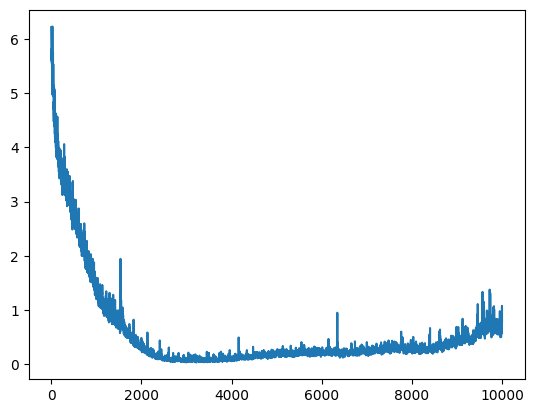

In [12]:
# plot losses
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()


In [18]:
logits, loss = model(inputs.to(device), labels.to(device))
for p in logits.argmax(dim=-1):
  print(p)

tensor([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
         29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
         43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
        113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        126, 128, 129, 130, 131, 132, 133, 133, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 166, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [14]:
"""
model has been trained and we now want a quantitative measure of its goodness. Lets implement perplexity to evaluate the model.
"""
def perplexity():
    model.eval()
    with torch.no_grad():
        inputs, labels = get_inputs_labels(batch_size=8)
        logits, loss = model(inputs.to(device), labels.to(device))
    return torch.exp(loss).item()

In [15]:
perplexity()

1.3995702266693115